# Exam

> Data: **2020-09-04**
>
> Autore: **Luigi Malaguti**

##

---

## Parte 0: Il Dataset

Il file weather.csv contiene dati meteo rilevati in alcune città australiane. Si vuole predire se il giorno successivo pioverà. Lo schema del dataset è il seguente:

- Month: mese in cui avviene la rilevazione del dato
- Location: città in cui avviene la rilevazione
- MinTemp, MaxTemp: temperature minima e massima
- Rainfall: quantitativo di pioggia caduta
- WindGustSpeed, WindSpeed9am, WindSpeed3pm: misurazioni relative al vento
- Humidity9am, Humidity3pm: misurazioni relative all’umidità
- Pressure9am, Pressure3pm: misurazioni relative alla pressione
- Cloud3pm: nuvolosità in ottavi: https://it.wikipedia.org/wiki/Okta
- Temp9am, Temp3pm: misurazioni relative alla temperatura
- RainToday, Yes/No
- RainTomorrow, la classe da predire

Note: Creare una cartella esame e scaricare in essa il file csv che si trova al [link](http://bit.ly/BDAweather2018).

### Imports

In [1]:
!curl -sLo dataset.csv "http://dbgroup.ing.unimo.it/~guerra/esamiBDA/weather.csv"
# !unzip -o dataset.zip
# !mv file.csv dataset.csv
# FILE_ID = "file_id"
# !curl -sLo dataset.csv "https://drive.google.com/uc?export=download&id={FILE_ID}"

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

### Dataset

In [3]:
df = pd.read_csv("dataset.csv", sep=";")

#### Overview

In [4]:
df.head()

,Month,Location,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,1,Albury,20.4,37.6,0.0,54,0,7,46,17,1013.4,1009.2,3,26.1,36.7,No,No
1,1,Albury,20.9,33.6,0.4,50,9,17,54,30,1011.1,1008.4,8,24.8,31.7,No,Yes
2,1,Albury,18.4,23.1,2.2,48,11,39,62,67,1014.0,1014.8,8,21.8,19.5,Yes,Yes
3,1,Albury,17.3,23.7,15.6,39,9,17,74,65,1017.9,1016.5,8,19.2,21.6,Yes,Yes
4,1,Albury,15.5,22.9,6.8,31,6,9,92,63,1016.3,1013.9,8,17.2,22.2,Yes,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14468 entries, 0 to 14467
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Month          14468 non-null  int64  
 1   Location       14468 non-null  object 
 2   MinTemp        14468 non-null  float64
 3   MaxTemp        14468 non-null  float64
 4   Rainfall       14468 non-null  float64
 5   WindGustSpeed  14468 non-null  int64  
 6   WindSpeed9am   14468 non-null  int64  
 7   WindSpeed3pm   14468 non-null  int64  
 8   Humidity9am    14468 non-null  int64  
 9   Humidity3pm    14468 non-null  int64  
 10  Pressure9am    14468 non-null  float64
 11  Pressure3pm    14468 non-null  float64
 12  Cloud3pm       14468 non-null  int64  
 13  Temp9am        14468 non-null  float64
 14  Temp3pm        14468 non-null  float64
 15  RainToday      14468 non-null  object 
 16  RainTomorrow   14468 non-null  object 
dtypes: float64(7), int64(7), object(3)
memory usage: 1

#### Instances

In [6]:
df.shape

(14468, 17)

#### Missing values

In [7]:
df.isnull().sum().sum()

np.int64(0)

#### Balancing

In [8]:
df["RainTomorrow"].value_counts()

,count
RainTomorrow,
No,11038
Yes,3430


<Axes: >

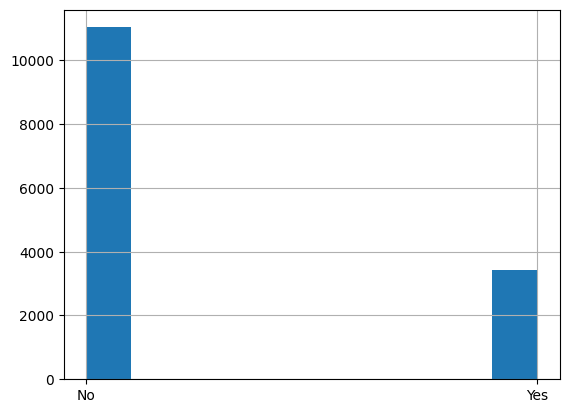

In [9]:
df["RainTomorrow"].hist()

##

---

## Parte 1: Analisi (Punti 10)

### Domanda 01 (Punti 2)

Quante sono le istanze contenute nel dataset? Il dataset è completo (cioè non esistono valori nulli)? Il dataset è bilanciato per quanto riguarda la classe da predire? Il numero di rilevazioni per città è bilanciato?

In [10]:
df.shape[0]

14468

> Il dataset contiene 14468 istanze.

In [11]:
df.isnull().sum().sum()

np.int64(0)

> Il dataset risulta essere completo, non contiene nessun missing value.

In [12]:
df["RainTomorrow"].value_counts()

,count
RainTomorrow,
No,11038
Yes,3430


> No, il dataset non è bilanciato per quanto riguarda `RainTomorrow`, sono presenti molte più istanze `No` rispetto a `Yes`.

<Axes: xlabel='Location'>

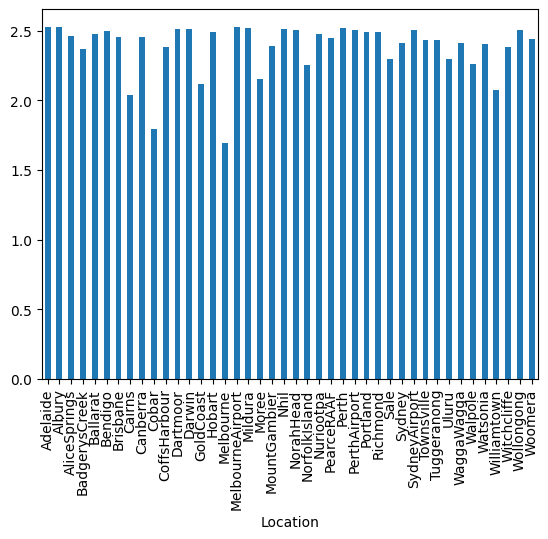

In [13]:
(df.groupby("Location")["RainTomorrow"].count() / len(df) * 100).plot(kind="bar")

> Le rilevazioni per città risultano essere abbastanza bilanciate, l'intervallo maggiore risulta essere di 1% circa, come ad esempio tra Adelaide e Melbourne.

---

### Domanda 02 (Punti 3)

Rappresentare in un grafico la frequenza delle rilevazioni mensili per città.

In [14]:
city_per_month = df.groupby(["Location", "Month"])["RainTomorrow"].count().unstack()
city_per_month.head()

Month,1,2,3,4,5,6,7,8,9,10,11,12
Location,,,,,,,,,,,,
Adelaide,31.0,29.0,31.0,30.0,31.0,30.0,31.0,31.0,30.0,31.0,30.0,31.0
Albury,31.0,29.0,31.0,30.0,31.0,30.0,31.0,31.0,30.0,31.0,30.0,31.0
AliceSprings,31.0,29.0,31.0,29.0,30.0,30.0,30.0,31.0,30.0,30.0,30.0,25.0
BadgerysCreek,28.0,29.0,31.0,30.0,31.0,30.0,31.0,31.0,29.0,31.0,29.0,13.0
Ballarat,29.0,27.0,30.0,30.0,31.0,29.0,31.0,31.0,30.0,30.0,30.0,30.0


<Axes: xlabel='Location', ylabel='Mean counts per month'>

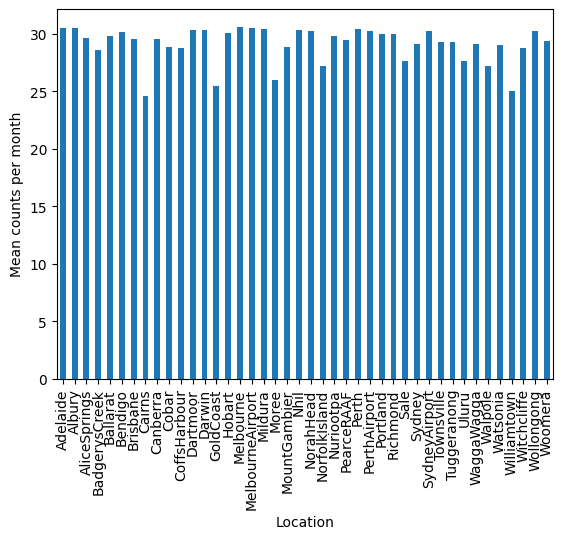

In [15]:
city_per_month.mean(axis=1).plot(kind="bar", ylabel="Mean counts per month")

---

### Domanda 03 (Punti 3)

Calcolare per ogni città e per ogni mese l’umidità minima e la massima.

In [16]:
df.groupby(["Location", "Month"])[["Humidity9am", "Humidity3pm"]].min().min(axis=1).unstack()

Month,1,2,3,4,5,6,7,8,9,10,11,12
Location,,,,,,,,,,,,
Adelaide,11.0,13.0,19.0,15.0,32.0,40.0,36.0,28.0,30.0,16.0,12.0,10.0
Albury,13.0,15.0,10.0,21.0,32.0,50.0,52.0,43.0,45.0,40.0,14.0,11.0
AliceSprings,13.0,5.0,5.0,7.0,5.0,10.0,10.0,11.0,8.0,5.0,3.0,4.0
BadgerysCreek,21.0,24.0,30.0,25.0,23.0,32.0,32.0,35.0,31.0,23.0,18.0,23.0
Ballarat,9.0,13.0,15.0,20.0,36.0,51.0,66.0,47.0,61.0,36.0,34.0,16.0
Bendigo,10.0,10.0,13.0,18.0,41.0,49.0,43.0,46.0,48.0,23.0,16.0,12.0
Brisbane,43.0,32.0,44.0,38.0,22.0,32.0,27.0,27.0,20.0,20.0,19.0,43.0
Cairns,40.0,47.0,48.0,51.0,56.0,47.0,48.0,37.0,57.0,44.0,24.0,42.0
Canberra,11.0,15.0,12.0,20.0,30.0,45.0,40.0,34.0,40.0,30.0,20.0,17.0


In [17]:
df.groupby(["Location", "Month"])[["Humidity9am", "Humidity3pm"]].max().max(axis=1).unstack()

Month,1,2,3,4,5,6,7,8,9,10,11,12
Location,,,,,,,,,,,,
Adelaide,93.0,76.0,93.0,84.0,93.0,96.0,97.0,96.0,96.0,95.0,71.0,89.0
Albury,96.0,88.0,98.0,100.0,100.0,100.0,100.0,100.0,100.0,98.0,98.0,93.0
AliceSprings,98.0,61.0,98.0,49.0,94.0,97.0,83.0,97.0,83.0,100.0,59.0,99.0
BadgerysCreek,100.0,95.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,89.0,87.0
Ballarat,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,99.0
Bendigo,94.0,79.0,89.0,92.0,97.0,98.0,99.0,99.0,99.0,98.0,92.0,88.0
Brisbane,86.0,75.0,90.0,85.0,92.0,94.0,97.0,89.0,87.0,87.0,88.0,82.0
Cairns,87.0,95.0,95.0,98.0,86.0,97.0,98.0,97.0,93.0,94.0,76.0,82.0
Canberra,94.0,96.0,99.0,93.0,99.0,99.0,99.0,99.0,99.0,94.0,86.0,94.0


---

### Domanda 04 (Punti 2)

Creare un nuovo attributo "TemperatureRange" che mostri l’escursione termica giornaliera. Rappresentare in un grafico l’escursione massima mensile.

<Axes: xlabel='Month'>

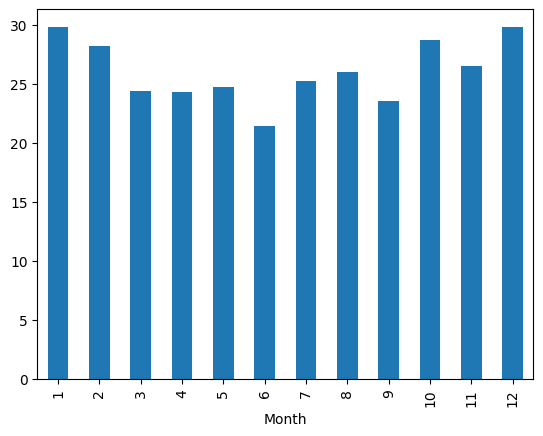

In [18]:
df["TemperatureRange"] = df["MaxTemp"] - df["MinTemp"]
df.groupby("Month")["TemperatureRange"].max().plot(kind="bar")

##

---

## Parte 2: Trasformazione e Predizione (Punti 20)

### Domanda 01 (Punti 4)

Si vuole predire la possibilità di avere pioggia il giorno successivo (RainTomorrow è la classe da predire). Trasformare i valori degli attributi RainToday e RainTomorrow da No a 0, e da Yes a 1. Creare un nuovo dataset chiamato reduce con le istanze del dataset per le quali c’è un valore di Cloud3pm maggiore o uguale a 0.

Dividere il dataset in modo che 4/5 degli elementi siano contenuti in un nuovo dataset "train" e 1/5 in un dataset "test". Valutare l’accuracy ottenuta con il classificatore Logistic Regression e il Decision Tree.

Il valore di accuratezza ottenuto è pari a? La confusion matrix evidenzia delle peculiarità?

In [19]:
df = pd.read_csv("dataset.csv", sep=";")
df["RainToday"] = df["RainToday"].map({"No": 0, "Yes": 1})
df["RainTomorrow"] = df["RainTomorrow"].map({"No": 0, "Yes": 1})
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df["Location"] = encoder.fit_transform(df[["Location"]])
reduced = df[df["Cloud3pm"] >= 0]

In [20]:
X, y = reduced.drop(columns=["RainTomorrow"]), reduced["RainTomorrow"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/5, stratify=y, random_state=0)

In [21]:
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=0),
    "LogisticRegression": LogisticRegression(max_iter=5000, n_jobs=-1, random_state=0),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print(name)
    print("=" * 30)
    print("TRAIN")
    print("    Accuracy:", accuracy_score(y_train, y_pred_train))
    print("    F1 score:", f1_score(y_train, y_pred_train))
    print(confusion_matrix(y_train, y_pred_train))
    print("-" * 30)
    print("TEST")
    print("    Accuracy:", accuracy_score(y_test, y_pred_test))
    print("    F1 score:", f1_score(y_test, y_pred_test))
    print(confusion_matrix(y_test, y_pred_test))
    print("=" * 30)
    print()

DecisionTree
TRAIN
    Accuracy: 1.0
    F1 score: 1.0
[[4799    0]
 [   0 1876]]
------------------------------
TEST
    Accuracy: 0.7615338526063511
    F1 score: 0.5845511482254697
[[991 209]
 [189 280]]

LogisticRegression
TRAIN
    Accuracy: 0.8112359550561797
    F1 score: 0.6132596685082873
[[4416  383]
 [ 877  999]]
------------------------------
TEST
    Accuracy: 0.8130617136009587
    F1 score: 0.6231884057971014
[[1099  101]
 [ 211  258]]



> Possiamo notare come il modello `LogisticRegression` abbai una accuracy maggiore rispetto al modello `DecisionTree`, rispettivamente di 81% e di 76% sul dataset di test. Per quanto riguarda il dataset di train, il modello `DecisionTree` apprende perfettamente, contro il `LogisticRegression` che presenta le stesse performance del dataset di test.
>
> Dalla cofusion matrix possiamo notare come il modello `DecisionTree` commetta errori in modo abbastanza distribuito sul dataset di test, mentre il modello `LogisticRegression` commette il doppio degli errori sulla classe 1, ovvero predice molte volte 0 quando in realtà l'istanza era classificata 1.

---

### Domanda 02 (Punti 2)

Che valore di accuratezza si ottiene con un 5 Fold cross validation e il classificatore basato su Decision Tree? E quello basato su Logistic Regression? Il valore di accuratezza maggiormente rappresentativo è quello che si ottiene con questa tecnica o con quella attuata in precedenza?

In [22]:
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(name)
    print("=" * 30)
    print("TRAIN")
    print("    Score mean:", scores.mean())
    print("    Scores:", scores)
    print("-" * 30)
    print("TEST")
    print("    Score mean:", scores.mean())
    print("    Scores:", scores)
    print("=" * 30)
    print()

DecisionTree
TRAIN
    Score mean: 0.7303434903365504
    Scores: [0.73337328 0.71899341 0.73996405 0.74295986 0.71642686]
------------------------------
TEST
    Score mean: 0.7303434903365504
    Scores: [0.73337328 0.71899341 0.73996405 0.74295986 0.71642686]

LogisticRegression
TRAIN
    Score mean: 0.8069247657595913
    Scores: [0.81006591 0.79508688 0.82384661 0.81845416 0.78717026]
------------------------------
TEST
    Score mean: 0.8069247657595913
    Scores: [0.81006591 0.79508688 0.82384661 0.81845416 0.78717026]



> I valori di accuratezza ottenuti dal `DecisionTree` e dal `LogisticRegression` attraverso un 5 fold cross validation risultano essere leggermente minori rispetto ai valori ottenuti attraverso il metodo precedente.

---

### Domanda 03 (Punti 4)

Si introduca un attributo che sostituisca per ogni rilevazione i due valori di temperatura "MinTemp, MaxTemp" con il valore medio delle registrazioni. Si faccia lo stesso con vento (WindSpeed9am, WindSpeed3pm). Che valore di accuratezza si ottiene?

In [23]:
df["MeanTemp"] = (df["MaxTemp"] + df["MinTemp"]) / 2
df["MeanWindSpeed"] = (df["WindSpeed9am"] + df["WindSpeed3pm"]) / 2

In [24]:
X, y = reduced.drop(columns=["RainTomorrow", "MinTemp", "MaxTemp", "WindSpeed9am", "WindSpeed3pm"]), reduced["RainTomorrow"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/5, stratify=y, random_state=0)

In [25]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print(name)
    print("=" * 30)
    print("TRAIN")
    print("    Accuracy:", accuracy_score(y_train, y_pred_train))
    print("    F1 score:", f1_score(y_train, y_pred_train))
    print(confusion_matrix(y_train, y_pred_train))
    print("-" * 30)
    print("TEST")
    print("    Accuracy:", accuracy_score(y_test, y_pred_test))
    print("    F1 score:", f1_score(y_test, y_pred_test))
    print(confusion_matrix(y_test, y_pred_test))
    print("=" * 30)
    print()

DecisionTree
TRAIN
    Accuracy: 1.0
    F1 score: 1.0
[[4799    0]
 [   0 1876]]
------------------------------
TEST
    Accuracy: 0.7477531455961653
    F1 score: 0.5655314757481941
[[974 226]
 [195 274]]

LogisticRegression
TRAIN
    Accuracy: 0.807940074906367
    F1 score: 0.6081907090464548
[[4398  401]
 [ 881  995]]
------------------------------
TEST
    Accuracy: 0.8154583582983823
    F1 score: 0.624390243902439
[[1105   95]
 [ 213  256]]



> Il valori di accuracy ottenuti attraverso questo nuovo dataset risultano essere pressoché analoghe alle precedenti, seppur leggermente inferiori per il modello `DecisionTree`.

---

### Domanda 04 (Punti 4)

Si riparta dal dataset originario e si considerino due nuovi dataset ottenuti rimuovendo dal dataset di partenza gli elementi con Cloud3pm minore di 0. Il dataset con i valori negativi si chiamerà cloudP, l’altro cloudT. Si alleni un regressore su cloudT per predire i valori di Cloud3pm. Si usi il modello per sostituire in cloudP il valore predetto per Cloud3pm.

In [26]:
df = pd.read_csv("dataset.csv", sep=";")
df["RainToday"] = df["RainToday"].map({"No": 0, "Yes": 1})
df["RainTomorrow"] = df["RainTomorrow"].map({"No": 0, "Yes": 1})
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df["Location"] = encoder.fit_transform(df[["Location"]])

cloud_t = df[df["Cloud3pm"] >= 0].copy()
cloud_p = df[df["Cloud3pm"] < 0].copy()

In [27]:
X, y = cloud_t.drop("Cloud3pm", axis=1), cloud_t["Cloud3pm"]
logistic_regression = models["LogisticRegression"]
logistic_regression.fit(X, y)
cloud_p["Cloud3pm"] = logistic_regression.predict(cloud_p.drop("Cloud3pm", axis=1))

---

### Domanda 05 (Punti 3)

Si consideri il dataset ottenuto concatenando cloudP e cloudT in un unico dataset e si confronti l’accuratezza che si ottiene con un 10 Fold cross validation e il classificatore basato su Decision Tree e quello basato su Logistic Regression con quella ottenuta al punto 3.

In [28]:
cloud = pd.concat([cloud_t, cloud_p])

In [29]:
X, y = cloud.drop("RainTomorrow", axis=1), cloud["RainTomorrow"]

In [30]:
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=10)
    print(name)
    print("=" * 30)
    print("TRAIN")
    print("    Score mean:", scores.mean())
    print("    Scores:", scores)
    print("-" * 30)
    print("TEST")
    print("    Score mean:", scores.mean())
    print("    Scores:", scores)
    print("=" * 30)
    print()

DecisionTree
TRAIN
    Score mean: 0.7213956284811137
    Scores: [0.73324119 0.70076019 0.67104354 0.61921216 0.71389081 0.64754665
 0.73600553 0.79751209 0.77731674 0.81742739]
------------------------------
TEST
    Score mean: 0.7213956284811137
    Scores: [0.73324119 0.70076019 0.67104354 0.61921216 0.71389081 0.64754665
 0.73600553 0.79751209 0.77731674 0.81742739]

LogisticRegression
TRAIN
    Score mean: 0.8284541585060328
    Scores: [0.83137526 0.77747063 0.85625432 0.82861092 0.82446441 0.80373186
 0.79336558 0.83759502 0.85062241 0.88105118]
------------------------------
TEST
    Score mean: 0.8284541585060328
    Scores: [0.83137526 0.77747063 0.85625432 0.82861092 0.82446441 0.80373186
 0.79336558 0.83759502 0.85062241 0.88105118]



> I valori di accuratezza per il modello `DecisionTree` calano di un altro paio di punti percentuali, quindi rispetto alle performance del modello al punto due, le performance risultano leggermente peggiori. Per il modello `LogisticRegression`, invece, sono leggermente migliorate, anche se solo di un punto percentuale.

---

### Domanda 06 (Punti 3)

Utilizzare un algoritmo di regressione da applicarsi al dataset del punto 1 per effettuare la predizione. Arrotondare i valori predetti all’intero. Confrontare i risultati ottenuti con quelli ottenuti nei punti precedenti.

In [31]:
df = pd.read_csv("dataset.csv", sep=";")
df["RainToday"] = df["RainToday"].map({"No": 0, "Yes": 1})
df["RainTomorrow"] = df["RainTomorrow"].map({"No": 0, "Yes": 1})
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df["Location"] = encoder.fit_transform(df[["Location"]])

In [32]:
X, y = reduced.drop(columns=["RainTomorrow"]), reduced["RainTomorrow"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/5, stratify=y, random_state=0)

In [33]:
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)
y_pred_train = np.round(linear_regression.predict(X_train)).astype(int)
y_pred_test = np.round(linear_regression.predict(X_test)).astype(int)
print("LinearRegression")
print("=" * 30)
print("TRAIN")
print("    Accuracy:", accuracy_score(y_train, y_pred_train))
print("    F1 score:", f1_score(y_train, y_pred_train, average="weighted"))
print(confusion_matrix(y_train, y_pred_train))
print("-" * 30)
print("TEST")
print("    Accuracy:", accuracy_score(y_test, y_pred_test))
print("    F1 score:", f1_score(y_test, y_pred_test, average="weighted"))
print(confusion_matrix(y_test, y_pred_test))
print("=" * 30)

LinearRegression
TRAIN
    Accuracy: 0.8067415730337079
    F1 score: 0.7943143012183745
[[4450  349    0]
 [ 940  935    1]
 [   0    0    0]]
------------------------------
TEST
    Accuracy: 0.8100659077291792
    F1 score: 0.7991575071665054
[[1109   91]
 [ 226  243]]


> Il modello `LinearRegression` sembra comportarsi discretamente, ottenendo valori di accuracy simili a quelli ottenuti da parte del modello `LogisticRegression`.